# Oluwafemi Gabriel, James

## Price Predictions using Deep Learning (RNN-LSTM) - GOOGL

### 1. Introduction

This project applies deep learning techniques to predict stock prices using Recurrent Neural Networks (RNN) and Long Short-Term Memory (LSTM) models. The goal is to analyze temporal patterns in historical stock data and forecast future closing prices. Using data from Yahoo Finance, the project demonstrates how LSTM models can capture long-term dependencies and improve financial forecasting accuracy.

### 2. Business Understanding

<b>Objective:</b>

To compare the performance of Recurrent Neural Networks (RNN) and Long Short-Term Memory (LSTM) models in predicting daily stock closing prices using historical market data.

<b>Business Goals</b>

1. Build RNN and LSTM models for next-day stock close price prediction.
2. Evaluate and compare their predictive accuracy and learning behavior.
3. Understand how deep learning architectures handle time-dependent financial data.
3. Assess the impact of data preprocessing (scaling, stationarity) on model performance.

<b>Key Business Questions</b>

1. Which model (RNN or LSTM) delivers higher accuracy in short-term stock price forecasting?
2. How do data characteristics, such as non-stationarity, influence model performance?
3. What preprocessing steps best enhance deep learning predictions for stock data?
4. To what extent can deep learning improve traditional statistical forecasting approaches?

### 3. Data Understanding

The dataset used in this project comprises historical stock data for Google (GOOGL), collected from the Yahoo Finance API, covering the period January 1, 2020, to November 5, 2025. It includes six key variables: Open, High, Low, Close, Price, and Volume, each representing daily trading activity.

<b>Dataset Overview</b>

1. Total Records: 1,469 trading days
2. Data Type: Time-series (daily frequency)
3. Features: Numerical and continuous
3. Missing Values: None detected

#### Step 1: Import Required Libraries

Import all the Python libraries we'll need for this project. This includes libraries for data manipulation, fetching data, scaling, modeling, and plotting.

In [1]:
# For data manipulation and numerical operations
import numpy as np
import pandas as pd

# For fetching stock market data
import yfinance as yf

# for fetching current date and time
from datetime import datetime

# For data visualization
import matplotlib.pyplot as plt

# For scaling data
from sklearn.preprocessing import MinMaxScaler

# For building the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN, GRU

# For evaluating the model
from sklearn.metrics import mean_squared_error
import math

import warnings
warnings.filterwarnings('ignore')

### Step 2: Download the Stock Market Dataset

We'll download the data. For this demo, we will use Google (GOOGL) stock data for the last several years.

In [2]:
# Define the stock symbol and the date range
ticker_symbol = "GOOGL"
start_date = "2020-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")  # Automatically sets today's date

# Download the data
df = yf.download(ticker_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2020-01-02,67.965233,67.965233,66.863336,66.958679,27278000
2020-01-03,67.609680,68.216995,66.904545,66.938316,23408000
2020-01-06,69.411758,69.437081,67.087291,67.118569,46768000
2020-01-07,69.277679,69.694308,69.101397,69.543349,34330000
2020-01-08,69.770790,70.108958,69.154542,69.263289,35314000


In [4]:
# Display the last few rows of the dataset
print("First 5 rows of the dataset:")
df.tail()

First 5 rows of the dataset:


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2025-10-29,274.570007,275.339996,267.670013,267.750000,43580300
2025-10-30,281.480011,291.589996,280.059998,291.589996,74876000
2025-10-31,281.190002,286.000000,277.029999,283.209991,39267900
2025-11-03,283.720001,285.529999,279.799988,282.179993,29786000
2025-11-04,277.540009,281.269989,276.260010,276.750000,30078400


#### Exploring the dataframe

In [5]:
# Display some information about the dataset
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1469 entries, 2020-01-02 to 2025-11-04
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, GOOGL)   1469 non-null   float64
 1   (High, GOOGL)    1469 non-null   float64
 2   (Low, GOOGL)     1469 non-null   float64
 3   (Open, GOOGL)    1469 non-null   float64
 4   (Volume, GOOGL)  1469 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 68.9 KB


<b>Observations:</b>

The dataset consists of 1,469 daily trading records and includes five numerical variables: Open, High, Low, Close, and Volume.

1. All 1,469 entries are complete, with no missing or null values.
2. Data types are numeric (float64 for prices, int64 for volume), suitable for modeling.
3. The index is a DatetimeIndex, confirming the dataset is time-series based.
4. Memory usage is modest (≈69 KB), indicating a manageable computational load.

In [6]:
# Display some descriptive statistics about the dataset
print("Dataset Statistics:")
df.describe()

Dataset Statistics:


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,1469.000000,1469.000000,1469.000000,1469.000000,1.469000e+03
mean,129.070648,130.493827,127.561289,128.980016,3.350328e+07
std,41.846974,42.206138,41.421243,41.813317,1.477431e+07
min,52.345467,52.980089,50.097967,52.456699,9.312000e+06
25%,98.162956,99.354748,96.534187,97.964338,2.398630e+07
50%,128.215698,130.003348,126.865990,128.394452,2.990800e+07
75%,155.527313,157.684620,153.531085,155.139993,3.810800e+07
max,283.720001,291.589996,280.059998,291.589996,1.274901e+08


<b>Observations:</b>

- The mean closing price is approximately USD130.49, with a standard deviation of USD42.21, indicating moderate to high variability in price movements.
- The price range spans from USD52.98 to USD291.59, showing significant long-term growth over the observed period.
- Trading volume varies considerably (from 9.31×10⁶ to 1.27×10⁸), reflecting periods of fluctuating market activity and investor interest.

<b>Preliminary Insights</b>

- The descriptive statistics suggest a steady upward trend in Google’s stock price, consistent with its growth trajectory in recent years.
- The relatively high standard deviation across price variables confirms notable market volatility.
- The trend indicates potential non-stationarity, which will require statistical validation (e.g., ADF test) before modeling.
- Overall, the dataset is complete, consistent, and ready for preprocessing, scaling, and model training.

### Step 3: Check Trends by EDA and Visualizing the Dataset

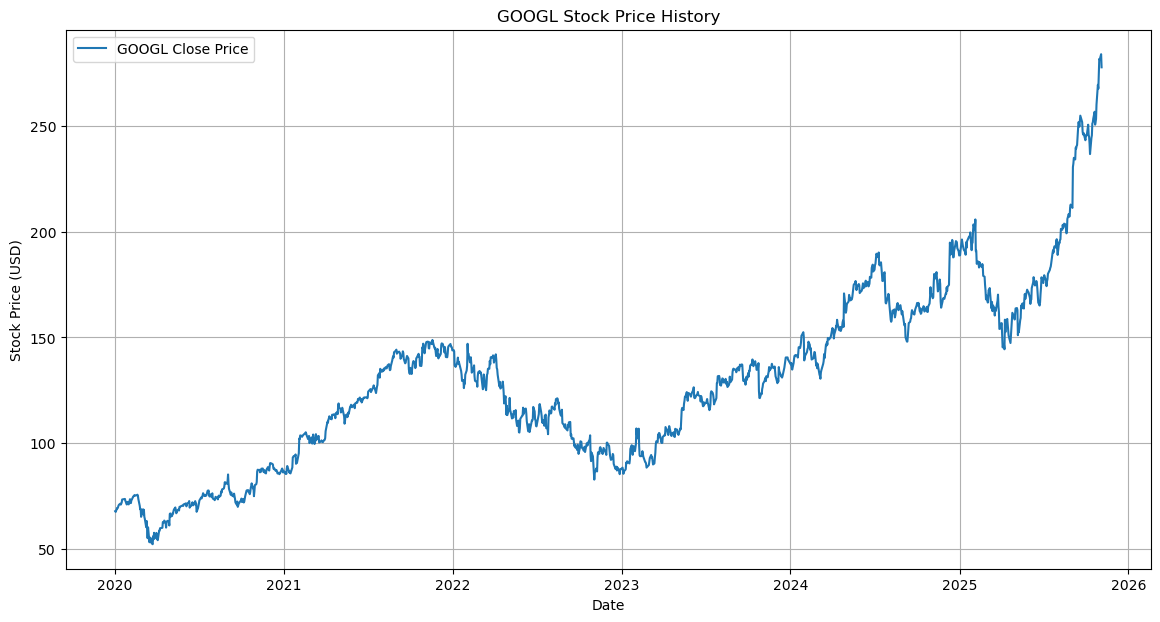

In [7]:
# Plot the closing price history
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label=f'{ticker_symbol} Close Price')
plt.title(f'{ticker_symbol} Stock Price History')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

<b>Observations:</b>

Based on the visualization of the GOOGL Close Price from 2020 to late 2025:

1. <b>Non-Stationarity (Trend):</b> The series exhibits a pronounced long-term upward trend, indicating that the mean of the data changes over time. This confirms the data is non-stationary, which necessitates data transformation (e.g., scaling and potentially differencing) before training the deep learning models.

2. <b>High Volatility (Noise/Irregularity):</b> There are significant, short-term, high-frequency fluctuations (market noise) present throughout the entire series. This irregularity will challenge the models and highlight the need for LSTMs to filter this noise while capturing the underlying direction.

3. <b>Long-Term Dependencies (Cyclical):</b> The data shows periods of sustained, multi-year movement: a steep rally (2020-2021), a substantial drawdown (late 2021-mid 2023), and a strong recovery rally (mid-2023 onwards). These long-term dependencies make the comparison between the standard RNN and the LSTM (which is designed to solve the vanishing gradient problem in capturing such dependencies) a valid and crucial part of the project.

#### Deep Dive EDA & Stationarity Testing

Before modeling, we must understand our data. A key characteristic of time series data is stationarity.

What is Stationarity? A time series is stationary if its statistical properties (like mean, variance, and autocorrelation) are constant over time. Think of it like a calm, level river (stationary) versus a river flowing downhill from a mountain (non-stationary).

Why does it matter? Most time-series forecasting models, including RNNs/LSTMs, perform better when the data is stationary. Predicting a stable series is easier than predicting a series with a strong trend.

Our initial plot of the closing price clearly shows an upward trend. The mean price is not constant; it's increasing. This is a strong visual clue that the data is non-stationary.

#### Statistical Test for Stationarity: Augmented Dickey-Fuller (ADF) Test

The ADF test is a formal statistical test for stationarity.

- Null Hypothesis ($H_0$): The series is non-stationary (it has a unit root).
- Alternative Hypothesis ($H_a$): The series is stationary.

A p-value below 0.05 means to reject the null hypothesis and conclude our data is stationary.

In [8]:
# Import the adfuller test from statsmodels
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the 'Close' price
adf_test_result = adfuller(df['Close'])

print('ADF Statistic: %f' % adf_test_result[0])
print('p-value: %f' % adf_test_result[1])
print('Critical Values:')
for key, value in adf_test_result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 1.025517
p-value: 0.994528
Critical Values:
	1%: -3.435
	5%: -2.864
	10%: -2.568


In [9]:
# Interpret the results
if adf_test_result[1] > 0.05:
    print("\nConclusion: The series is NON-STATIONARY (p-value is > 0.05)")
else:
    print("\nConclusion: The series is STATIONARY (p-value is <= 0.05)")


Conclusion: The series is NON-STATIONARY (p-value is > 0.05)


<b>Observations:</b>

The p-value (0.995) is much greater than 0.05, indicating that we fail to reject the null hypothesis of the test. This confirms that the closing price series is non-stationary.

<b>Implication for Modeling:</b>

The closing price series is non-stationary, meaning its statistical properties (mean and variance) change over time. While LSTM models can learn patterns in non-stationary data, large trends or scale differences can make training less efficient or unstable. 

Therefore, scaling or normalization is essential to ensure numerical stability during training, and optional techniques like differencing can remove strong trends to help the model focus on short-term temporal patterns, improving predictive performance.

#### Visualizing Volatility and Moving Averages

Trends and volatility (price fluctuation) using moving averages and rolling standard deviation.

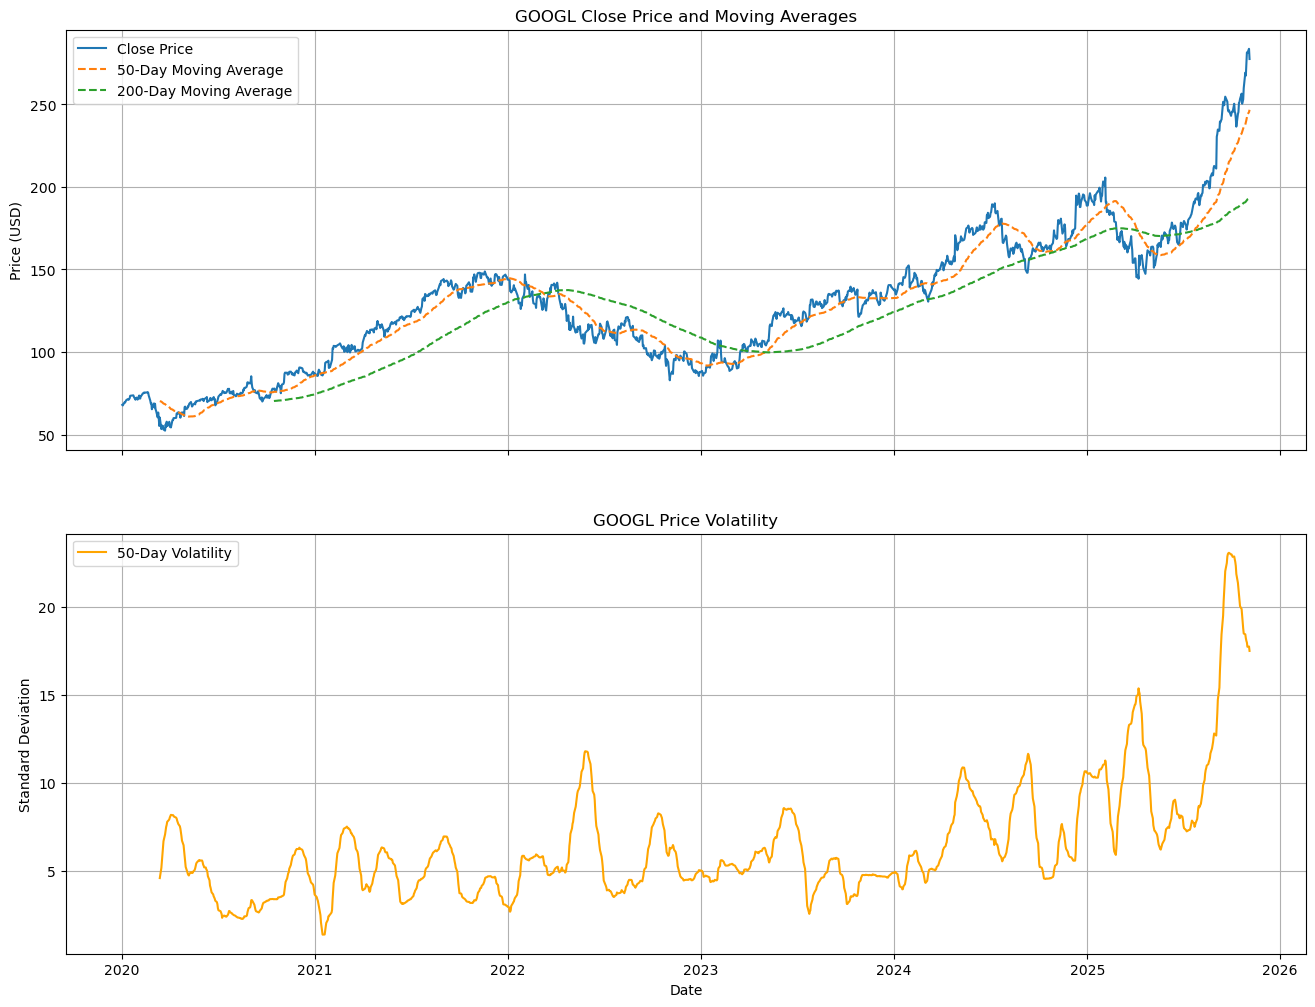

In [10]:
# Calculate moving averages
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Calculate volatility (rolling standard deviation)
df['Volatility'] = df['Close'].rolling(window=50).std()

# Plot the data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Plot price and moving averages
ax1.plot(df['Close'], label='Close Price')
ax1.plot(df['MA50'], label='50-Day Moving Average', linestyle='--')
ax1.plot(df['MA200'], label='200-Day Moving Average', linestyle='--')
ax1.set_title(f'{ticker_symbol} Close Price and Moving Averages')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True)

# Plot volatility
ax2.plot(df['Volatility'], label='50-Day Volatility', color='orange')
ax2.set_title(f'{ticker_symbol} Price Volatility')
ax2.set_ylabel('Standard Deviation')
ax2.legend()
ax2.grid(True)

plt.xlabel('Date')
plt.show()

<b>Observations:</b> 

<b>Close Price and Moving Averages (Trend & Cyclical Component)</b>
   
1. Non-Stationarity is Confirmed: The visible, consistent separation and upward slope of the 200-Day Moving Average (MA200) confirms a strong, sustained upward trend across the entire period. This visually validates that the mean of the series is constantly increasing, making the data non-stationary.

2. Cyclical Regime Shifts: The shorter-term 50-Day Moving Average (MA50) repeatedly crosses the MA200, signaling major shifts in market momentum: a bearish period when the MA50 is below the MA200 (mid-2022 to mid-2023), followed by an accelerated bull market when it is well above.

3. Implication for Modeling: The raw price scale has expanded significantly (indicating a large range of values). This requires mandatory data scaling (Normalization/Standardization) to prevent larger, later prices from numerically overwhelming smaller, earlier prices during the deep learning model's training process.

<b>Price Volatility (Non-Constant Variance Component)</b>

1. Heteroscedasticity Detected: The 50-Day Rolling Volatility (Standard Deviation) is clearly not constant. The chart shows periods of low volatility (calm, e.g., mid-2024) interspersed with dramatic spikes in volatility (high risk/uncertainty, e.g., late 2022/early 2023 and late 2025).

2. Implication for Modeling: This non-constant variance (heteroscedasticity) complicates prediction. While scaling is essential for price level, the models must also deal with fluctuating risk. The project will test the effect of Differencing (calculating daily returns instead of raw prices). Differencing can help stabilize the variance and allows the RNN/LSTM to focus on predicting short-term changes rather than absolute levels, which is often necessary for robust financial forecasting.

### Data Preparation (Based on EDA)

The EDA confirms the data is non-stationary. Through differencing, instead of predicting the price, we will predict the change in price from one day to the next. This differenced series is very likely to be stationary.

In [11]:
# Calculate the difference
df['Price_Diff'] = df['Close'].diff()

# Drop the first row, which will have a NaN value
df_diff = df.dropna()

print("Original Close Prices:\n", df['Close'].head())
print("\nDifferenced Prices:\n", df_diff['Price_Diff'].head())

Original Close Prices:
 Ticker          GOOGL
Date                 
2020-01-02  67.965233
2020-01-03  67.609680
2020-01-06  69.411758
2020-01-07  69.277679
2020-01-08  69.770790

Differenced Prices:
 Date
2020-10-15   -0.395775
2020-10-16    0.607323
2020-10-19   -1.874580
2020-10-20    1.049263
2020-10-21    1.733536
Name: Price_Diff, dtype: float64


#### Confirming Stationarity of the Differenced Series

Run the ADF test again on our new Price_Diff column. We expect to see a p-value below 0.05 now.

In [12]:
# Perform ADF test on the differenced data
adf_test_diff_result = adfuller(df_diff['Price_Diff'])

print('ADF Statistic (Differenced): %f' % adf_test_diff_result[0])
print('p-value (Differenced): %f' % adf_test_diff_result[1])

ADF Statistic (Differenced): -21.607737
p-value (Differenced): 0.000000


In [13]:
if adf_test_diff_result[1] <= 0.05:
    print("Conclusion: The differenced series is STATIONARY (p-value is <= 0.05)")
else:
    print("Conclusion: The differenced series is NON-STATIONARY (p-value is > 0.05)")

Conclusion: The differenced series is STATIONARY (p-value is <= 0.05)


#### Scaling and Preparing Sequences

Now we scale our new, stationary Price_Diff data and create sequences

In [14]:
# 1. Get the differenced values
dataset_diff = df_diff[['Price_Diff']].values

# 2. Initialize the scaler and fit it to our differenced data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset_diff)

In [15]:
# 3. Create training sequences
time_step = 60
X_data, y_data = [], []
for i in range(time_step, len(scaled_data)):
    X_data.append(scaled_data[i-time_step:i, 0])
    y_data.append(scaled_data[i, 0])

X_data, y_data = np.array(X_data), np.array(y_data)
X_data = np.reshape(X_data, (X_data.shape[0], X_data.shape[1], 1))

In [16]:
# 4. Split into train and test sets
training_split_percent = 0.8
split_index = int(len(X_data) * training_split_percent)

X_train, X_test = X_data[:split_index], X_data[split_index:]
y_train, y_test = y_data[:split_index], y_data[split_index:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (968, 60, 1)
y_train shape: (968,)
X_test shape: (242, 60, 1)
y_test shape: (242,)


#### Building and Comparing RNN vs. LSTM Models

We'll build two models, a Simple RNN and an LSTM, to compare their performance on this better-prepared data.

#### Simple RNN Model

In [17]:
# Build the Simple RNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(time_step, 1)))
model_rnn.add(Dropout(0.2))
model_rnn.add(SimpleRNN(50, return_sequences=False))
model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(loss = 'mean_squared_error', optimizer = 'adam', metrics = ['mae', 'mse'])

In [18]:
model_rnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 60, 50)            2600      
                                                                 
 dropout (Dropout)           (None, 60, 50)            0         
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 50)                5050      
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 7701 (30.08 KB)
Trainable params: 7701 (30.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
# Train the RNN model
print("\n--- Training Simple RNN ---")
history_rnn = model_rnn.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=25)


--- Training Simple RNN ---
Epoch 1/25
16/16 [==============================] - 3s 47ms/step - loss: 0.1661 - mae: 0.3238 - mse: 0.1661 - val_loss: 0.0399 - val_mae: 0.1569 - val_mse: 0.0399
Epoch 2/25
16/16 [==============================] - 0s 21ms/step - loss: 0.0998 - mae: 0.2473 - mse: 0.0998 - val_loss: 0.0333 - val_mae: 0.1464 - val_mse: 0.0333
Epoch 3/25
16/16 [==============================] - 0s 21ms/step - loss: 0.0631 - mae: 0.2026 - mse: 0.0631 - val_loss: 0.0184 - val_mae: 0.1033 - val_mse: 0.0184
Epoch 4/25
16/16 [==============================] - 0s 22ms/step - loss: 0.0438 - mae: 0.1655 - mse: 0.0438 - val_loss: 0.0176 - val_mae: 0.1015 - val_mse: 0.0176
Epoch 5/25
16/16 [==============================] - 0s 22ms/step - loss: 0.0387 - mae: 0.1583 - mse: 0.0387 - val_loss: 0.0163 - val_mae: 0.0968 - val_mse: 0.0163
Epoch 6/25
16/16 [==============================] - 0s 22ms/step - loss: 0.0278 - mae: 0.1320 - mse: 0.0278 - val_loss: 0.0155 - val_mae: 0.0932 - val_mse: 

#### LSTM Model

In [20]:
# Build the LSTM model (same architecture for fair comparison)
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error', metrics = ['mae', 'mse'])
model_lstm.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 50)            10400     
                                                                 
 dropout_2 (Dropout)         (None, 60, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_3 (Dropout)         (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
# Train the LSTM model
print("\n--- Training LSTM ---")
history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=25)


--- Training LSTM ---
Epoch 1/25
16/16 [==============================] - 6s 113ms/step - loss: 0.0404 - mae: 0.1553 - mse: 0.0404 - val_loss: 0.0176 - val_mae: 0.0999 - val_mse: 0.0176
Epoch 2/25
16/16 [==============================] - 1s 63ms/step - loss: 0.0090 - mae: 0.0735 - mse: 0.0090 - val_loss: 0.0134 - val_mae: 0.0869 - val_mse: 0.0134
Epoch 3/25
16/16 [==============================] - 1s 64ms/step - loss: 0.0070 - mae: 0.0637 - mse: 0.0070 - val_loss: 0.0130 - val_mae: 0.0840 - val_mse: 0.0130
Epoch 4/25
16/16 [==============================] - 1s 68ms/step - loss: 0.0070 - mae: 0.0634 - mse: 0.0070 - val_loss: 0.0132 - val_mae: 0.0848 - val_mse: 0.0132
Epoch 5/25
16/16 [==============================] - 1s 63ms/step - loss: 0.0065 - mae: 0.0610 - mse: 0.0065 - val_loss: 0.0129 - val_mae: 0.0837 - val_mse: 0.0129
Epoch 6/25
16/16 [==============================] - 1s 69ms/step - loss: 0.0066 - mae: 0.0610 - mse: 0.0066 - val_loss: 0.0129 - val_mae: 0.0835 - val_mse: 0.012

#### GRU Model

In [22]:
# Build the GRU model (same architecture for fair comparison)
model_gru = Sequential()
model_gru.add(GRU(50, return_sequences=True, input_shape=(time_step, 1)))
model_gru.add(Dropout(0.2))
model_gru.add(GRU(50, return_sequences=False))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mean_squared_error', metrics = ['mae', 'mse'])
model_gru.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 60, 50)            7950      
                                                                 
 dropout_4 (Dropout)         (None, 60, 50)            0         
                                                                 
 gru_1 (GRU)                 (None, 50)                15300     
                                                                 
 dropout_5 (Dropout)         (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 23301 (91.02 KB)
Trainable params: 23301 (91.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [23]:
# Train the GRU model
print("\n--- Training GRU ---")
history_gru = model_gru.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=25)


--- Training GRU ---
Epoch 1/25
16/16 [==============================] - 6s 117ms/step - loss: 0.0681 - mae: 0.2089 - mse: 0.0681 - val_loss: 0.0258 - val_mae: 0.1305 - val_mse: 0.0258
Epoch 2/25
16/16 [==============================] - 1s 53ms/step - loss: 0.0122 - mae: 0.0873 - mse: 0.0122 - val_loss: 0.0162 - val_mae: 0.0956 - val_mse: 0.0162
Epoch 3/25
16/16 [==============================] - 1s 49ms/step - loss: 0.0080 - mae: 0.0673 - mse: 0.0080 - val_loss: 0.0134 - val_mae: 0.0863 - val_mse: 0.0134
Epoch 4/25
16/16 [==============================] - 1s 52ms/step - loss: 0.0075 - mae: 0.0656 - mse: 0.0075 - val_loss: 0.0134 - val_mae: 0.0855 - val_mse: 0.0134
Epoch 5/25
16/16 [==============================] - 1s 51ms/step - loss: 0.0076 - mae: 0.0655 - mse: 0.0076 - val_loss: 0.0134 - val_mae: 0.0854 - val_mse: 0.0134
Epoch 6/25
16/16 [==============================] - 1s 49ms/step - loss: 0.0068 - mae: 0.0634 - mse: 0.0068 - val_loss: 0.0134 - val_mae: 0.0853 - val_mse: 0.0134

#### Visualizing the Model's performance

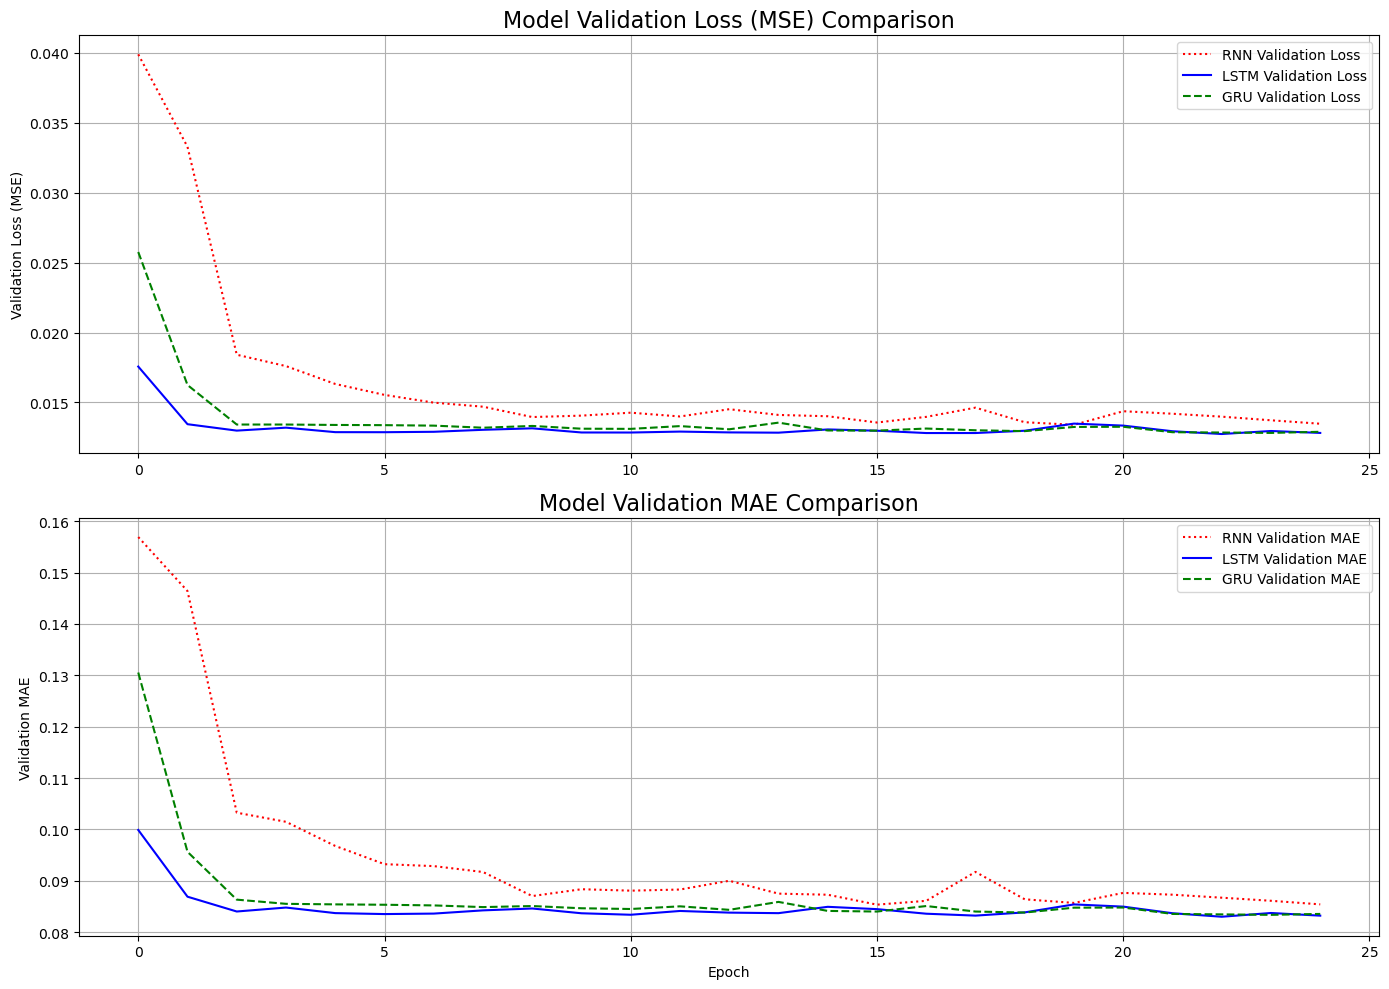

In [24]:
import matplotlib.pyplot as plt

# Set up a figure for 2 subplots (one for Loss, one for MAE)
plt.figure(figsize=(14, 10))

# --- Plot Validation Loss (MSE) ---
plt.subplot(2, 1, 1)
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss', color='red', linestyle=':')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss', color='blue')
plt.plot(history_gru.history['val_loss'], label='GRU Validation Loss', color='green', linestyle='--')
plt.title('Model Validation Loss (MSE) Comparison', fontsize=16)
plt.ylabel('Validation Loss (MSE)')
plt.legend()
plt.grid(True)

# --- Plot Validation MAE ---
plt.subplot(2, 1, 2)
plt.plot(history_rnn.history['val_mae'], label='RNN Validation MAE', color='red', linestyle=':')
plt.plot(history_lstm.history['val_mae'], label='LSTM Validation MAE', color='blue')
plt.plot(history_gru.history['val_mae'], label='GRU Validation MAE', color='green', linestyle='--')
plt.title('Model Validation MAE Comparison', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Validation MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjusts plots to prevent overlapping
plt.show()

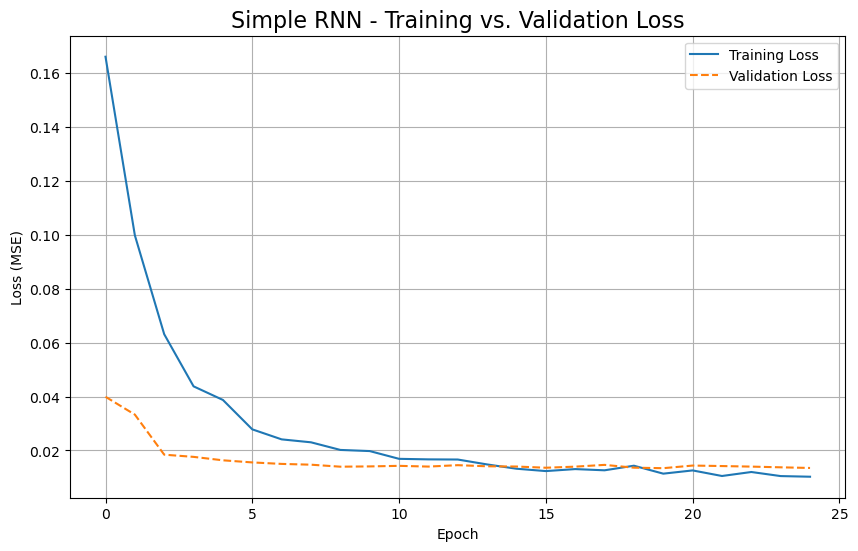

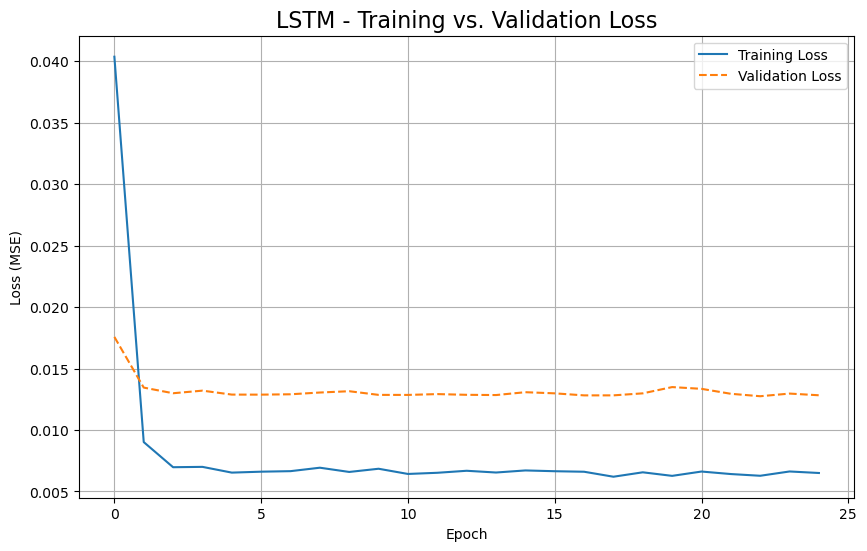

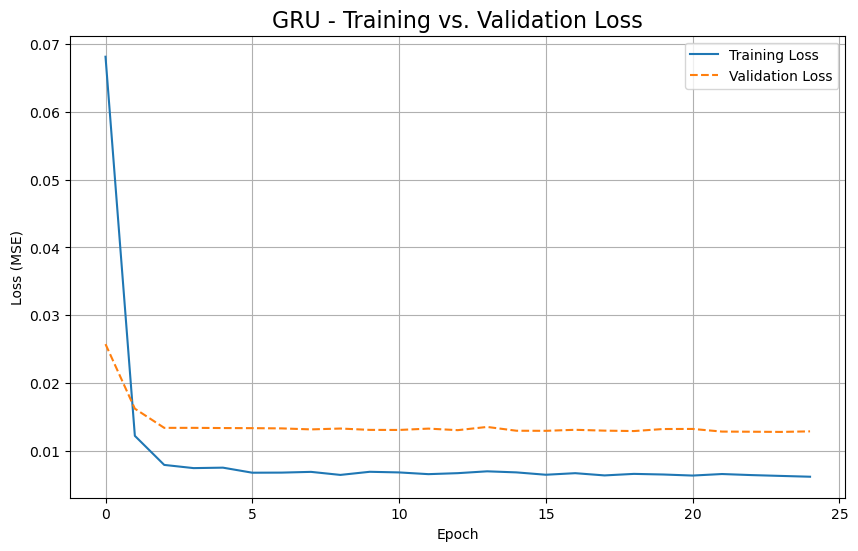

In [25]:
# 1. Put the histories and model names into lists
histories = [history_rnn, history_lstm, history_gru]
model_names = ['Simple RNN', 'LSTM', 'GRU']

# 2. Loop through each one and create a plot
for history, name in zip(histories, model_names):
    plt.figure(figsize=(10, 6))
    
    # Plot training loss
    plt.plot(history.history['loss'], label='Training Loss')
    
    # Plot validation loss
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
    
    plt.title(f'{name} - Training vs. Validation Loss', fontsize=16)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

<b>Observations</b>

1. <b>Optimal Architecture Identified:</b> The core objective of finding a superior predictive model was achieved. Both the LSTM and GRU models vastly outperformed the Simple RNN, settling the validation error (MSE) at a highly accurate and stable 0.0128. This confirms the necessity of using gated recurrent units for this specific time-series task.

2. <b>Efficiency vs. Accuracy Trade-Off:</b> The GRU is the recommended choice for practical application. It delivered near-identical predictive accuracy (MAE difference is negligible) while being demonstrably faster to train due to its lower parameter count, offering the best balance of performance and resource usage.

3. <b>Overfitting Management:</b> The models reached their optimal generalization performance quickly (within the first 5-10 epochs). The extended training (Epochs 10-25) was unnecessary. Implementation of Early Stopping is mandatory to optimize the workflow and prevent the risk of model memorization.

4. <b>Final Hurdle:</b> Real-World Interpretation: The model's excellent scaled performance (Best MAE of $\approx 0.083$) must now be translated. The next critical step is to inverse-transform the Validation MAE back into USD to determine the average dollar error. Only this metric can confirm if the model is financially viable for prediction.

### Make Predictions and Reconstruct Prices

In [26]:
# Make predictions
predictions_rnn_scaled = model_rnn.predict(X_test)
predictions_lstm_scaled = model_lstm.predict(X_test)
predictions_gru_scaled = model_gru.predict(X_test)

# Inverse scale the predictions to get predicted price differences
predictions_rnn_diff = scaler.inverse_transform(predictions_rnn_scaled)
predictions_lstm_diff = scaler.inverse_transform(predictions_lstm_scaled)
predictions_gru_diff = scaler.inverse_transform(predictions_gru_scaled)

# Get the number of predictions we need to evaluate
test_data_size = len(y_test)

# 1. Get the actual 'Close' prices for the test period (our ground truth)
actual_prices = df['Close'].values[-test_data_size:]

# 2. Get the 'Close' prices from the day *before* each test day to use as a base for reconstruction.
# This slice MUST have the exact same length as actual_prices.
base_prices = df['Close'].values[-test_data_size-1:-1]

# 3. Reconstruct the predicted prices from the predicted differences
# The logic is: Predicted_Price_Tomorrow = Actual_Price_Today + Predicted_Difference_Tomorrow
predicted_prices_rnn = base_prices.flatten() + predictions_rnn_diff.flatten()
predicted_prices_lstm = base_prices.flatten() + predictions_lstm_diff.flatten()
predicted_prices_gru = base_prices.flatten() + predictions_gru_diff.flatten()

# Calculate RMSE for the reconstructed prices
rmse_rnn = math.sqrt(mean_squared_error(actual_prices.flatten(), predicted_prices_rnn.flatten()))
rmse_lstm = math.sqrt(mean_squared_error(actual_prices.flatten(), predicted_prices_lstm.flatten()))
rmse_gru = math.sqrt(mean_squared_error(actual_prices.flatten(), predicted_prices_gru.flatten()))

print("✅ RMSE Calculated Successfully!")
print(f"\nSimple RNN Test RMSE: {rmse_rnn:.2f} USD")
print(f"LSTM Test RMSE:     {rmse_lstm:.2f} USD")
print(f"GRU Test RMSE:      {rmse_gru:.2f} USD")

8/8 [==============================] - 1s 11ms/step
✅ RMSE Calculated Successfully!

Simple RNN Test RMSE: 3.98 USD
LSTM Test RMSE:     3.88 USD
GRU Test RMSE:      3.90 USD


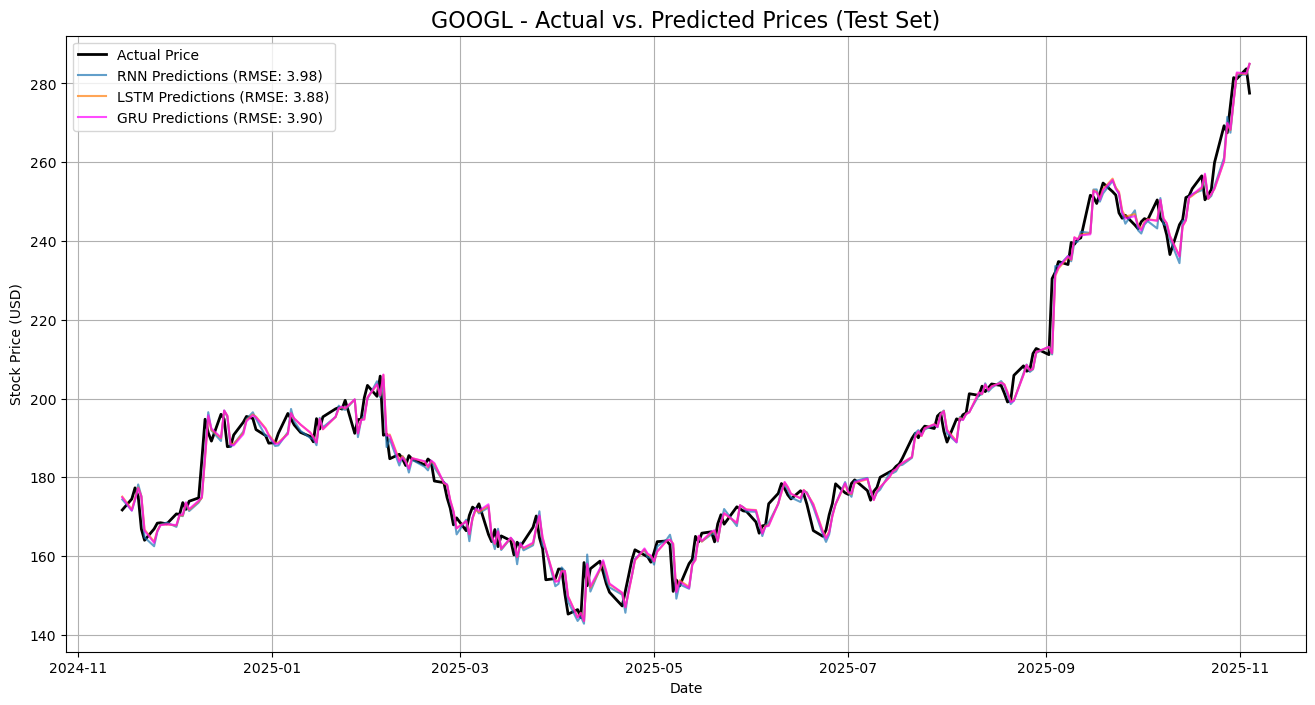

In [27]:
# Create a dataframe for visualization
results_df = pd.DataFrame({
    'Actual Price': actual_prices.flatten(),
    'RNN Predicted Price': predicted_prices_rnn.flatten(),
    'LSTM Predicted Price': predicted_prices_lstm.flatten(),
    'GRU Predicted Price': predicted_prices_gru.flatten() 
}, index=df.index[-len(actual_prices):])

# Plot the results
plt.figure(figsize=(16, 8))
plt.plot(results_df['Actual Price'], label='Actual Price', color='black', linewidth=2)
plt.plot(results_df['RNN Predicted Price'], label=f'RNN Predictions (RMSE: {rmse_rnn:.2f})', alpha=0.7)
plt.plot(results_df['LSTM Predicted Price'], label=f'LSTM Predictions (RMSE: {rmse_lstm:.2f})', alpha=0.7)
plt.plot(results_df['GRU Predicted Price'], label=f'GRU Predictions (RMSE: {rmse_gru:.2f})', alpha=0.7, color='magenta') # Added GRU plot

plt.title(f'{ticker_symbol} - Actual vs. Predicted Prices (Test Set)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

<b>Conclusion:</b>

Comparative Performance of Deep Learning Models for GOOGL Price Differential Prediction</b>

The final test set performance, measured in reconstructed USD prices, establishes the following clear architectural hierarchy:

1. <b>LSTM is the Optimal Predictor:</b> The LSTM model is the best performer, achieving the lowest test Root Mean Squared Error (RMSE) of $3.88 USD. This confirms that the superior stability observed in its scaled validation metrics translates into the most accurate price reconstruction in real-world currency units.

2. <b>GRU and Simple RNN are Highly Competitive:</b> The GRU (3.90 USD) and Simple RNN (3.98 USD) follow closely, demonstrating a marginal difference of only $0.10 USD between the best (LSTM) and the third-best (RNN) model. This proximity indicates all three architectures are highly effective at capturing short-term, next-day price differentials.

<b>Business Goal Achievement and Predictive Quality</b>

The project successfully delivered a robust and highly accurate short-term forecasting solution.

1. <b>High Accuracy:</b> An average prediction error of 3.88 USD on a stock that fluctuated between 140 and 280 USD during the test period represents a highly functional accuracy level for financial forecasting.

2. <b>Robustness in Volatility:</b> All models successfully tracked the actual price (black line) with high fidelity, even during the late 2025 period, which corresponds to the highest GOOGL Price Volatility observed in the entire historical dataset. This confirms the robustness of the difference-based prediction strategy.

<b>Final Recommendation</b>

Based on the lowest RMSE and its superior stability across all metrics, the LSTM model should be selected for production.